In [1]:
# Bibliothèques principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')


# TensorFlow et Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# KerasNLP pour BERT
import keras_nlp

# Sklearn pour métriques
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Keggle hub pour dataset
import kagglehub

import re
import os


# Configuration GPU
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU(s) détecté(s): {len(gpus)} - Croissance mémoire activée")
    else:
        print("⚠️  Aucun GPU détecté - Utilisation du CPU")
except Exception as e:
    print(f"Configuration GPU: {e}")

# Configuration graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

print(f"\n📦 TensorFlow version: {tf.__version__}")
print(f"📦 Keras version: {keras.__version__}")
print(f"📦 KerasNLP version: {keras_nlp.__version__}")

2026-04-06 16:26:06.611634: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-06 16:26:06.680893: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-06 16:26:08.237459: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✅ GPU(s) détecté(s): 1 - Croissance mémoire activée

📦 TensorFlow version: 2.20.0
📦 Keras version: 3.13.2
📦 KerasNLP version: 0.26.0


In [2]:
print("Récupération des données...")
# Récupérer les données
path = kagglehub.dataset_download("haideradnan77/mental-health-condition-classification")

for f in os.listdir(path):
    df = pd.read_csv(os.path.join(path, f))

print(".. OK")

print("Nombre d'entrées : ", df.shape[0])

df.head()

Récupération des données...
.. OK
Nombre d'entrées :  103488


,text,status
0,"""My mind is a never-ending cycle of worry, and...",anxiety
1,Despite the sun shining and birds singing outs...,bipolar
2,"I'm drowning in responsibilities, each one dem...",stress
3,"""My emotions shift like the wind, leaving me u...",personality disorder
4,"I'm trapped in a whirlwind of thoughts, unable...",anxiety


In [3]:
X_train_all, X_test_raw, y_train_all, y_test_raw = train_test_split(df["text"], df["status"], test_size=0.2, random_state=SEED)

# Créer un validation set
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_train_all, y_train_all, test_size=0.25, random_state=SEED, stratify=y_train_all
)

print(f"✅ Préparation terminée !")
print(f"\n📊 Répartition finale:")
print(f"   Train: {len(X_train_raw):,} elements")
print(f"   Validation: {len(X_val_raw):,} elements")
print(f"   Test: {len(X_test_raw):,} elements")


✅ Préparation terminée !

📊 Répartition finale:
   Train: 62,092 elements
   Validation: 20,698 elements
   Test: 20,698 elements


In [4]:
statuses = df.groupby("status")

CLASSES_COUNT = len(statuses)
print(f"Nous avons {CLASSES_COUNT} classes:")

for name, group in statuses:
    print("\t", name, len(group))


chart_values = [len(group) for _, group in statuses]
chart_labels = [name for name, _ in statuses]

Nous avons 7 classes:
	 anxiety 17620
	 bipolar 13708
	 depression 15901
	 normal 16068
	 personality disorder 13915
	 stress 15230
	 suicidal 11046


In [5]:
# labels
y_labels = chart_labels

y_train_array = y_train_raw.transform(lambda x: y_labels.index(x))
y_train = tf.keras.utils.to_categorical(y_train_array, num_classes=len(y_labels))

y_val_array = y_val_raw.transform(lambda x: y_labels.index(x))
y_val = tf.keras.utils.to_categorical(y_val_array, num_classes=len(y_labels))

y_test_array = y_test_raw.transform(lambda x: y_labels.index(x))
y_test = tf.keras.utils.to_categorical(y_test_array, num_classes=len(y_labels))

print(f"\n Dimensions des données :")
print(f"  y (output) : {y_train.shape} - (nombre_sequences, classes)")



 Dimensions des données :
  y (output) : (62092, 7) - (nombre_sequences, classes)


In [6]:
class LivePlotCallback(Callback):
    """
    Callback pour visualiser les métriques d'entraînement en temps réel.
    """
    def on_train_begin(self, logs=None):
        self.epochs = []
        self.loss = []
        self.val_loss = []
        self.accuracy = []
        self.val_accuracy = []
        
    def on_epoch_end(self, epoch, logs=None):
        # Enregistrement des métriques
        self.epochs.append(epoch + 1)
        self.loss.append(logs.get('loss'))
        self.val_loss.append(logs.get('val_loss'))
        self.accuracy.append(logs.get('accuracy'))
        self.val_accuracy.append(logs.get('val_accuracy'))
        
        # Effacement et redessin
        clear_output(wait=True)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
        
        # Graphique de la loss
        ax1.plot(self.epochs, self.loss, 'o-', label='Loss d\'entraînement',
                linewidth=2.5, markersize=8, color='#E63946')
        ax1.plot(self.epochs, self.val_loss, 's-', label='Loss de validation',
                linewidth=2.5, markersize=8, color='#F77F00')
        ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Loss (Categorical Crossentropy)', fontsize=12, fontweight='bold')
        ax1.set_title('Évolution de la Loss', fontsize=14, fontweight='bold')
        ax1.legend(fontsize=11, loc='upper right')
        ax1.grid(alpha=0.3)
        
        # Graphique de l'accuracy
        ax2.plot(self.epochs, self.accuracy, 'o-', label='Accuracy d\'entraînement',
                linewidth=2.5, markersize=8, color='#06AED5')
        ax2.plot(self.epochs, self.val_accuracy, 's-', label='Accuracy de validation',
                linewidth=2.5, markersize=8, color='#073B4C')
        ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
        ax2.set_title('Évolution de l\'Accuracy', fontsize=14, fontweight='bold')
        ax2.legend(fontsize=11, loc='lower right')
        ax2.grid(alpha=0.3)
        ax2.set_ylim([0, 1])
        
        plt.tight_layout()
        plt.show()
        
        # Affichage textuel
        print(f"\n{'='*70}")
        print(f"Epoch {epoch + 1}/{self.params['epochs']}")
        print(f"{'='*70}")
        print(f"Loss d'entraînement : {logs.get('loss'):.4f}")
        print(f"Accuracy d'entraînement : {logs.get('accuracy'):.4f} ({logs.get('accuracy')*100:.2f}%)")
        print(f"\nLoss de validation : {logs.get('val_loss'):.4f}")
        print(f"Accuracy de validation : {logs.get('val_accuracy'):.4f} ({logs.get('val_accuracy')*100:.2f}%)")
        print(f"{'='*70}")

print("✅ Callback de visualisation créé")

✅ Callback de visualisation créé


In [7]:
# Configuration
MAX_WORDS = 10000
MAX_LEN = 250

BATCH_SIZE=32
EPOCH_TL=30
EPOCH_FT=100

BERT_MODEL_NAME= "bert_medium_en_uncased"#, "bert_small_en_uncased","bert_medium_en_uncased"

In [8]:
# Charger le préprocesseur BERT de KerasNLP
print("📥 Chargement du preprocesseur BERT...\n")

# Utiliser le preprocesseur BERT pré-entraîné
preprocessor = keras_nlp.models.BertPreprocessor.from_preset(
    BERT_MODEL_NAME,
    sequence_length=128
)

print("✅ Preprocesseur chargé !")
print(f"\nVocabulaire: {preprocessor.tokenizer.vocabulary_size():,} tokens")
print(f"Longueur de séquence: 128")

📥 Chargement du preprocesseur BERT...

✅ Preprocesseur chargé !

Vocabulaire: 30,522 tokens
Longueur de séquence: 128


I0000 00:00:1775492771.612398  743482 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


In [9]:
def compile_model(model, learning_rate=1e-5):
        # Compiler
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_accuracy')]
    )

    return model

def create_frozen_bert_model(learning_rate=1e-5, dropout_rate=0.2, dense_units_count=128, dense_layers=1):
    """
    Crée un modèle BERT avec les poids gelés (Feature Extraction).
    """
    # Charger BERT pré-entraîné
    bert_backbone = keras_nlp.models.BertBackbone.from_preset(
        BERT_MODEL_NAME,  # Version légère
        trainable=False  # GELÉ
    )
    
    # Input
    inputs = {
        "token_ids": layers.Input(shape=(128,), dtype=tf.int32, name="token_ids"),
        "segment_ids": layers.Input(shape=(128,), dtype=tf.int32, name="segment_ids"),
        "padding_mask": layers.Input(shape=(128,), dtype=tf.int32, name="padding_mask"),
    }
    
    # BERT Encoder
    bert_output = bert_backbone(inputs)["sequence_output"]
    
    # Prendre le [CLS] token (première position)
    cls_token = bert_output[:, 0, :]
    
    # Couches de classification
    x = layers.Dropout(dropout_rate)(cls_token)
    for _ in range(0, dense_layers):
        x = layers.Dense(dense_units_count, activation='relu')(x)
        x = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(CLASSES_COUNT, activation='softmax', name='output')(x)
    
    model = keras.Model(inputs, output)
    
    # Compiler
    model = compile_model(model, learning_rate)
    return model, bert_backbone


# Créer le modèle
print("🔨 Création du modèle BERT (Feature Extraction)...\n")
bert_frozen_model, bert_backbone = create_frozen_bert_model()

print("✅ Modèle BERT (frozen) créé !\n")
bert_frozen_model.summary()

🔨 Création du modèle BERT (Feature Extraction)...

✅ Modèle BERT (frozen) créé !



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ padding_mask        │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_ids         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_backbone       │ [(None, 512),     │ 41,373,184 │ padding_mask[0][… │
│ (BertBackbone)      │ (None, 128, 512)] │            │ segment_ids[0][0… │
│                     │                   │            │ token_ids[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 512)       │          0 │ bert_backbone[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 512)       │          0 │ get_item_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     65,664 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 7)         │        903 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,439,751 (158.08 MB)

 Trainable params: 66,567 (260.03 KB)

 Non-trainable params: 41,373,184 (157.83 MB)

In [10]:
# Préprocesser les données
print("🔄 Preprocessing des données avec BERT...\n")

X_train_bert = preprocessor(X_train_raw)
X_val_bert = preprocessor(X_val_raw)
X_test_bert = preprocessor(X_test_raw)

print("✅ Preprocessing terminé !")

🔄 Preprocessing des données avec BERT...



2026-04-06 16:26:17.700834: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT64 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


✅ Preprocessing terminé !


In [11]:
live_plot = LivePlotCallback()
early_stop = EarlyStopping(monitor='val_accuracy', mode='max', patience=10, restore_best_weights=True, verbose=1)
reduce_on_plateau = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint(
    'best_model_frozen.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=0
)

print("Callbacks ok!")

Callbacks ok!


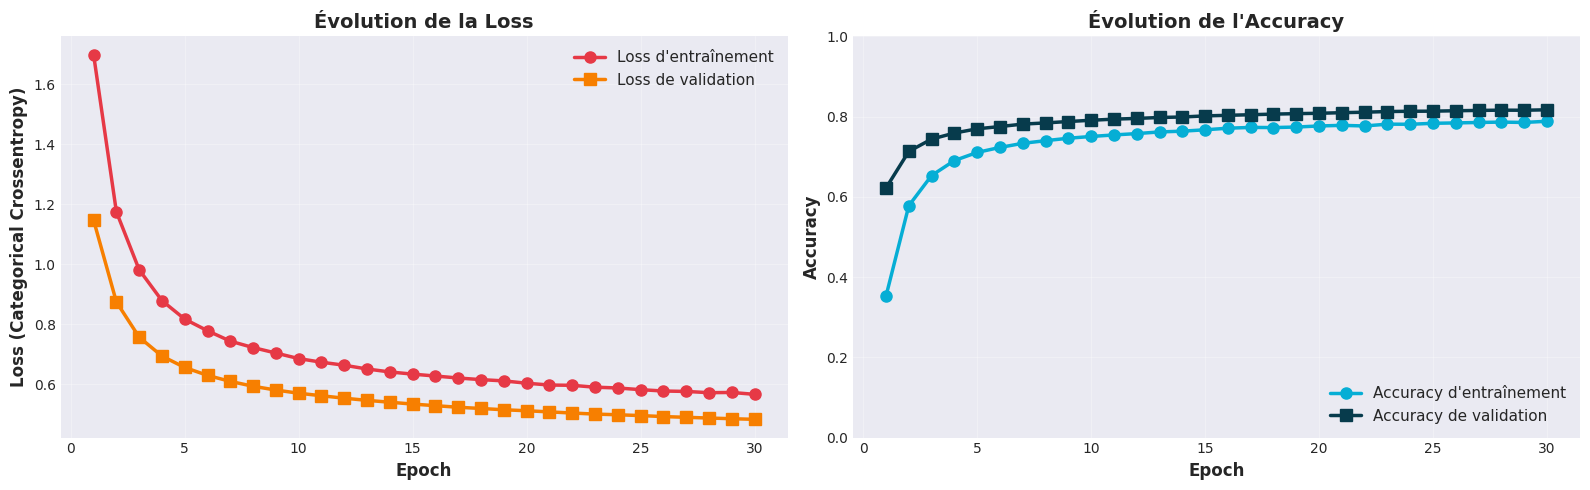


Epoch 30/30
Loss d'entraînement : 0.5656
Accuracy d'entraînement : 0.7884 (78.84%)

Loss de validation : 0.4821
Accuracy de validation : 0.8169 (81.69%)
1941/1941 ━━━━━━━━━━━━━━━━━━━━ 166s 86ms/step - accuracy: 0.7884 - loss: 0.5656 - top2_accuracy: 0.9208 - val_accuracy: 0.8169 - val_loss: 0.4821 - val_top2_accuracy: 0.9375 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 30.

 Entraînement BERT (frozen) terminé !
   Epochs effectués : 30
   Meilleure val_accuracy : 81.69% (epoch 30)

 Excellent ! Accuracy de 81.7%


In [12]:
# Entraînement
print("\n🚀 Entraînement BERT (Feature Extraction)...\n")

history_bert_frozen = bert_frozen_model.fit(
    X_train_bert,
    y_train,
    validation_data=(X_val_bert, y_val),
    epochs=EPOCH_TL,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[reduce_on_plateau, early_stop, checkpoint, live_plot],
)

print("\n Entraînement BERT (frozen) terminé !")
print(f"   Epochs effectués : {len(history_bert_frozen.history['loss'])}")

best_val_acc = max(history_bert_frozen.history['val_accuracy'])
best_epoch = history_bert_frozen.history['val_accuracy'].index(best_val_acc) + 1
print(f"   Meilleure val_accuracy : {best_val_acc*100:.2f}% (epoch {best_epoch})")

if best_val_acc < 0.70:
    print(f"\n  Accuracy de {best_val_acc*100:.1f}% est en dessous de 70%")
    print("   Le modèle pourrait bénéficier de plus d'entraînement.")
elif best_val_acc < 0.80:
    print(f"\n Bon résultat : {best_val_acc*100:.1f}%")
else:
    print(f"\n Excellent ! Accuracy de {best_val_acc*100:.1f}%")

In [13]:
X_test_bert = preprocessor(X_test_raw)
y_test_idx = np.argmax(y_test, axis=1)

y_pred_bert = bert_frozen_model.predict(X_test_bert, verbose=0)

y_pred_bert_idx = np.argmax(y_pred_bert, axis=1)

print("\n📈 Classification Report:")
print(classification_report(y_test_idx, y_pred_bert_idx, target_names=y_labels))



📈 Classification Report:
                      precision    recall  f1-score   support

             anxiety       0.85      0.90      0.87      3492
             bipolar       0.89      0.85      0.87      2764
          depression       0.63      0.65      0.64      3186
              normal       0.85      0.91      0.88      3223
personality disorder       0.96      0.93      0.94      2823
              stress       0.91      0.84      0.87      2963
            suicidal       0.60      0.57      0.58      2247

            accuracy                           0.82     20698
           macro avg       0.81      0.81      0.81     20698
        weighted avg       0.82      0.82      0.82     20698



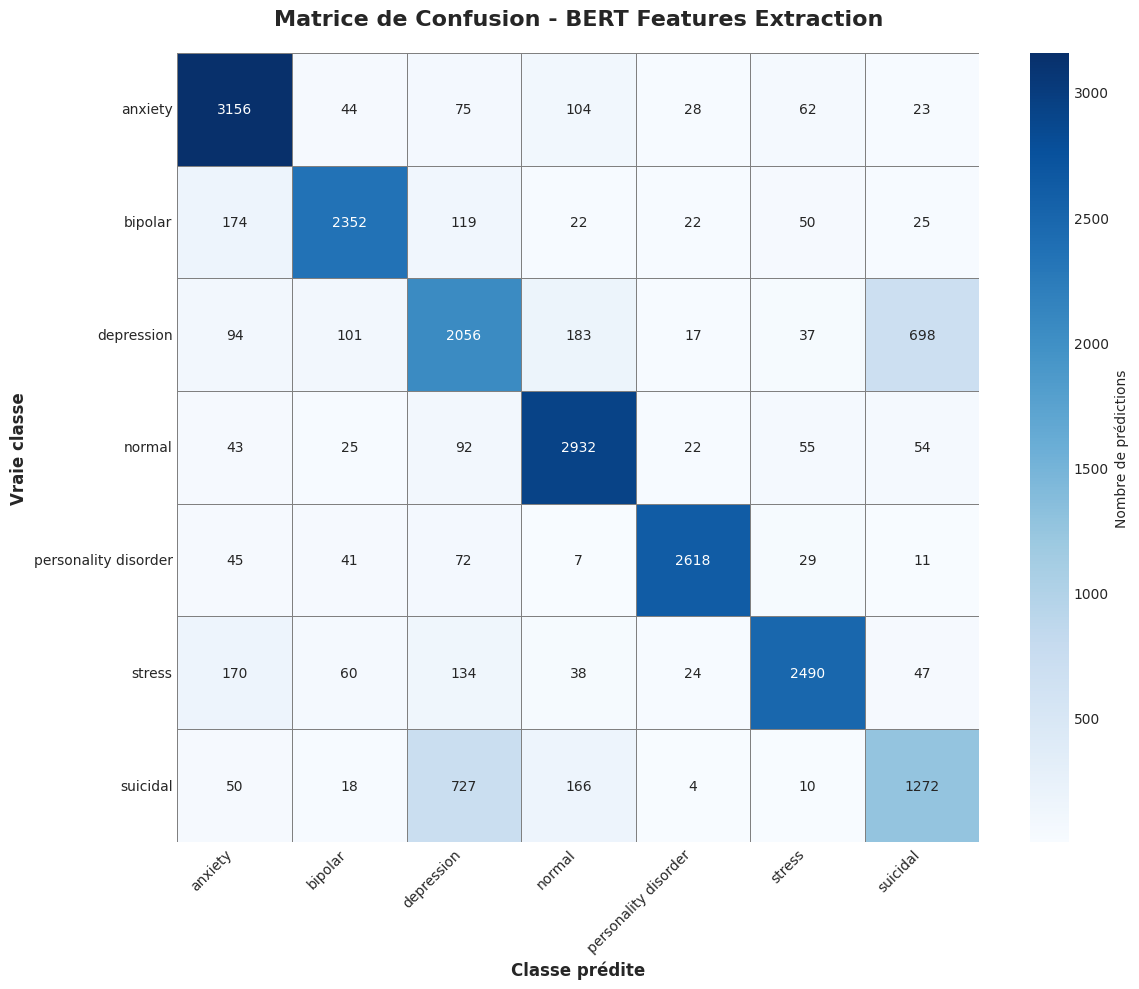

In [14]:
# Matrice de confusion
cm = confusion_matrix(y_test_idx, y_pred_bert_idx)

# Visualisation
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=y_labels, yticklabels=y_labels,
            cbar_kws={'label': 'Nombre de prédictions'},
            linewidths=0.5, linecolor='gray')
plt.title('Matrice de Confusion - BERT Features Extraction', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Vraie classe', fontsize=12, fontweight='bold')
plt.xlabel('Classe prédite', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
phrases = [
    "I don't feel like getting up, everything seems so dull",
    "Something's gonna happen here, something bad and I cannot do anything to prevent it",
    "Yesterday I was full of energy and enthusiasm, now I am totally down, what's happening?",
    "I got up, went to work, it was a wonderful day",
    "I would like to go to sleep and never wake up anymore", 
    "Everything is going so fast, my head is spinning, my heart is racing, I need a break"
]

preprocessed_phrases = preprocessor(phrases)
pred = bert_frozen_model.predict(preprocessed_phrases)
for idx, p in enumerate(pred):
    print(phrases[idx])
    print("It is", y_labels[np.argmax(p)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
I don't feel like getting up, everything seems so dull
It is normal
Something's gonna happen here, something bad and I cannot do anything to prevent it
It is normal
Yesterday I was full of energy and enthusiasm, now I am totally down, what's happening?
It is normal
I got up, went to work, it was a wonderful day
It is normal
I would like to go to sleep and never wake up anymore
It is normal
Everything is going so fast, my head is spinning, my heart is racing, I need a break
It is anxiety


In [16]:
# Évaluation AVANT fine-tuning
print("📈 Performance AVANT fine-tuning :")
results_before = bert_frozen_model.evaluate(X_val_bert, y_val, verbose=0)
print(f"  - Accuracy : {results_before[1]*100:.2f}%")
print(f"  - Loss     : {results_before[0]:.4f}\n")

bert_backbone.trainable = True

trainable_from = 10
for idx, layer in enumerate(bert_backbone.layers):
    if idx < trainable_from:
        layer.trainable = False
    else:
        layer.trainable = True

LR = 1e-5
bert_ft_model = compile_model(bert_frozen_model, LR)

bert_ft_model.summary()

print("\n🔍 Vérification immédiate :")
results_after_compile = bert_ft_model.evaluate(X_val_bert, y_val, verbose=0)
print(f"  - Accuracy : {results_after_compile[1]*100:.2f}%")
print(f"  - Loss     : {results_after_compile[0]:.4f}")

if abs(results_after_compile[1] - results_before[1]) < 0.01:
    print(f"\n  ✅ Parfait ! Les poids sont préservés ({results_after_compile[1]*100:.1f}%)")
else:
    print(f"\n  ⚠️  Les performances ont changé après recompilation")

📈 Performance AVANT fine-tuning :
  - Accuracy : 81.69%
  - Loss     : 0.4821



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ padding_mask        │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_ids         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_backbone       │ [(None, 512),     │ 41,373,184 │ padding_mask[0][… │
│ (BertBackbone)      │ (None, 128, 512)] │            │ segment_ids[0][0… │
│                     │                   │            │ token_ids[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 512)       │          0 │ bert_backbone[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 512)       │          0 │ get_item_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     65,664 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 7)         │        903 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,439,751 (158.08 MB)

 Trainable params: 22,395,911 (85.43 MB)

 Non-trainable params: 19,043,840 (72.65 MB)


🔍 Vérification immédiate :
  - Accuracy : 81.69%
  - Loss     : 0.4821

  ✅ Parfait ! Les poids sont préservés (81.7%)


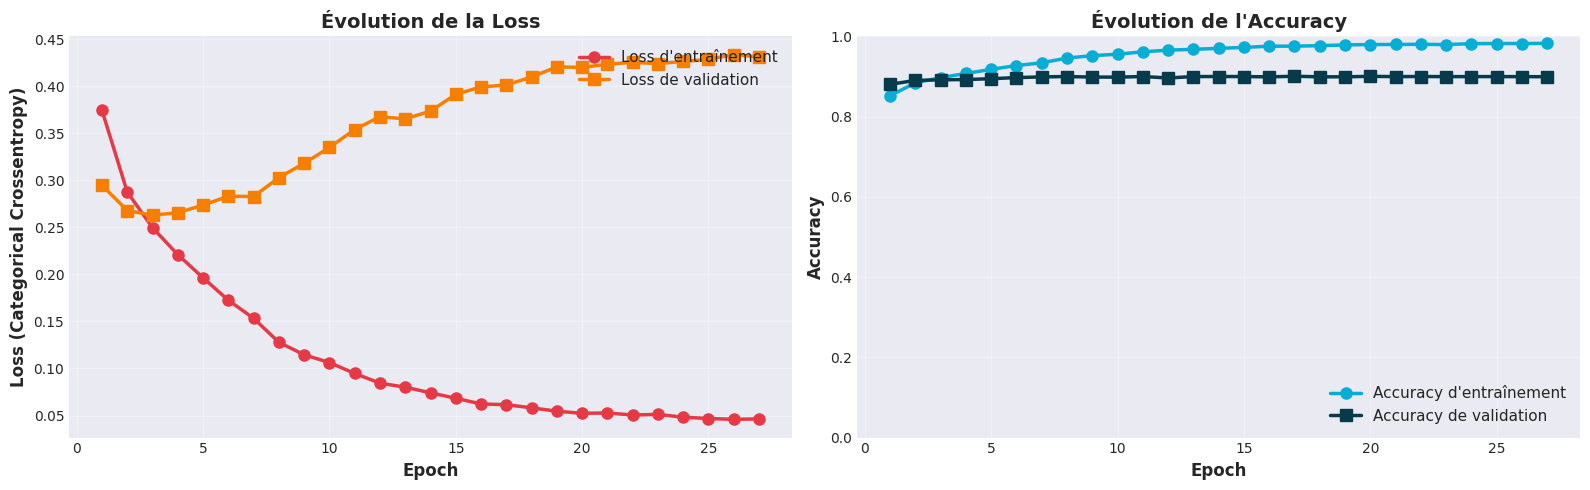


Epoch 27/100
Loss d'entraînement : 0.0464
Accuracy d'entraînement : 0.9825 (98.25%)

Loss de validation : 0.4310
Accuracy de validation : 0.8993 (89.93%)
1941/1941 ━━━━━━━━━━━━━━━━━━━━ 410s 211ms/step - accuracy: 0.9825 - loss: 0.0464 - top2_accuracy: 0.9996 - val_accuracy: 0.8993 - val_loss: 0.4310 - val_top2_accuracy: 0.9817 - learning_rate: 3.1250e-07
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 17.

Entraînement BERT (fine tuned) terminé !


In [17]:
# Entraînement
print("\nEntraînement BERT (Fine Tuning)...\n")

history_bert_ft = bert_ft_model.fit(
    X_train_bert,
    y_train,
    validation_data=(X_val_bert, y_val),
    epochs=EPOCH_FT,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[reduce_on_plateau, early_stop, live_plot, checkpoint],
)

print("\nEntraînement BERT (fine tuned) terminé !")

In [18]:
X_test_bert = preprocessor(X_test_raw)
y_test_idx = np.argmax(y_test, axis=1)

y_pred_bert = bert_ft_model.predict(X_test_bert, verbose=0)

y_pred_bert_idx = np.argmax(y_pred_bert, axis=1)

print("\n📈 Classification Report:")
print(classification_report(y_test_idx, y_pred_bert_idx, target_names=y_labels))


📈 Classification Report:
                      precision    recall  f1-score   support

             anxiety       0.95      0.97      0.96      3492
             bipolar       0.96      0.96      0.96      2764
          depression       0.78      0.69      0.74      3186
              normal       0.95      0.95      0.95      3223
personality disorder       0.98      0.98      0.98      2823
              stress       0.93      0.94      0.94      2963
            suicidal       0.67      0.74      0.70      2247

            accuracy                           0.90     20698
           macro avg       0.89      0.89      0.89     20698
        weighted avg       0.90      0.90      0.90     20698



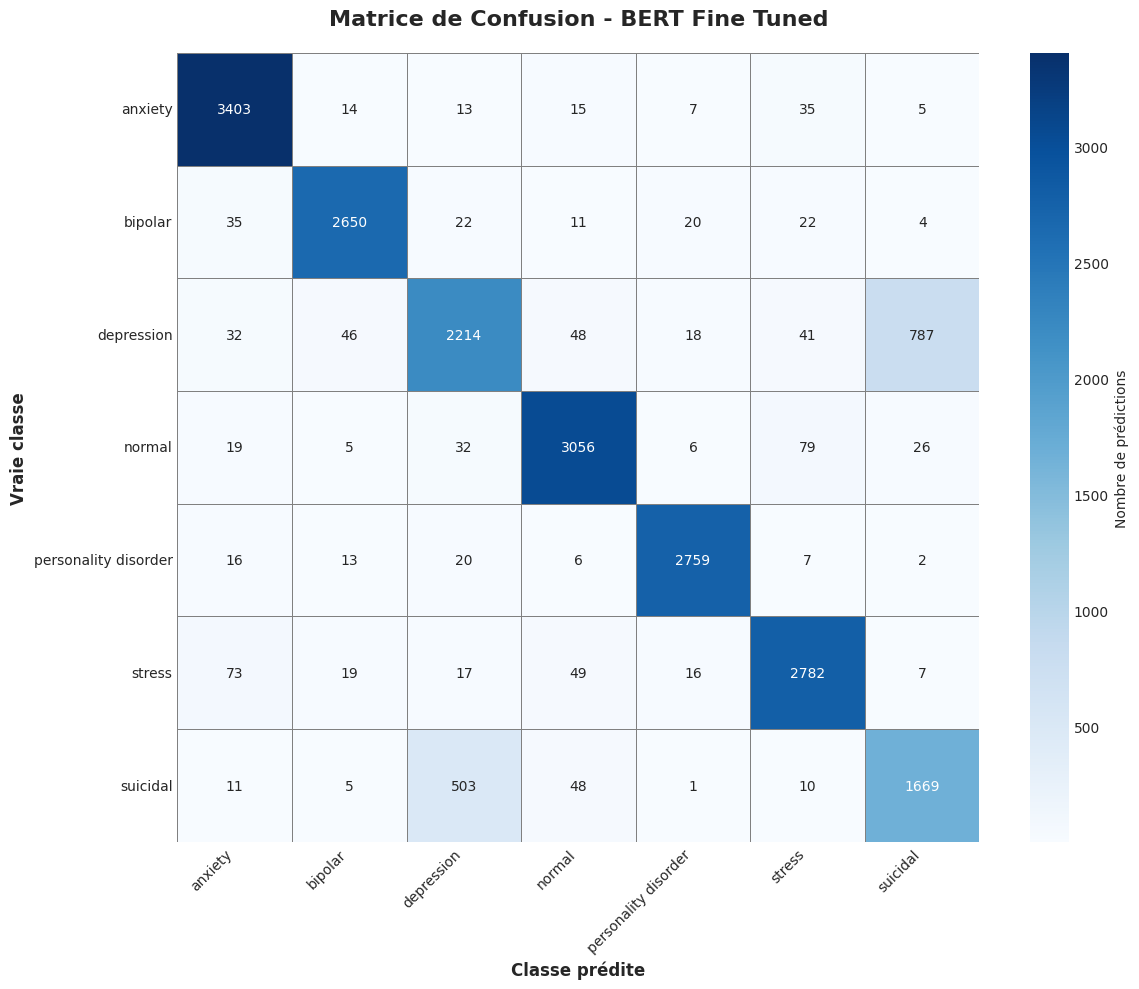

In [19]:
# Matrice de confusion
cm = confusion_matrix(y_test_idx, y_pred_bert_idx)

# Visualisation
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=y_labels, yticklabels=y_labels,
            cbar_kws={'label': 'Nombre de prédictions'},
            linewidths=0.5, linecolor='gray')
plt.title('Matrice de Confusion - BERT Fine Tuned', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Vraie classe', fontsize=12, fontweight='bold')
plt.xlabel('Classe prédite', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
phrases = [
    "I don't feel like getting up, everything seems so dull",
    "Something's gonna happen here, something bad and I cannot do anything to prevent it",
    "Yesterday I was full of energy and enthusiasm, now I am totally down, what's happening?",
    "I got up, went to work, it was a wonderful day",
    "I would like to go to sleep and never wake up anymore", 
    "Everything is going so fast, my head is spinning, my heart is racing, I need a break"
]

preprocessed_phrases = preprocessor(phrases)
pred = bert_ft_model.predict(preprocessed_phrases)
for idx, p in enumerate(pred):
    print(phrases[idx])
    print("It is",)
    for i in range(0, len(p)):
        print(y_labels[i], p[i])


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
I don't feel like getting up, everything seems so dull
It is
anxiety 0.0021286036
bipolar 5.861811e-05
depression 0.0025036524
normal 0.99440134
personality disorder 7.0228616e-06
stress 7.772291e-05
suicidal 0.00082305726
Something's gonna happen here, something bad and I cannot do anything to prevent it
It is
anxiety 0.0004570714
bipolar 3.4992381e-06
depression 0.2680127
normal 0.00018102702
personality disorder 2.1246615e-06
stress 0.00014714363
suicidal 0.73119646
Yesterday I was full of energy and enthusiasm, now I am totally down, what's happening?
It is
anxiety 1.9967476e-05
bipolar 0.00010998358
depression 8.62745e-05
normal 0.9997602
personality disorder 1.1078202e-08
stress 8.8074245e-07
suicidal 2.2733719e-05
I got up, went to work, it was a wonderful day
It is
anxiety 1.2030878e-07
bipolar 9.146563e-08
depression 1.4329008e-07
normal 0.9999995
personality disorder 4.8542803e-10
stress 4.1955083e-08
suicidal 1.7269123e-07
I would like to 

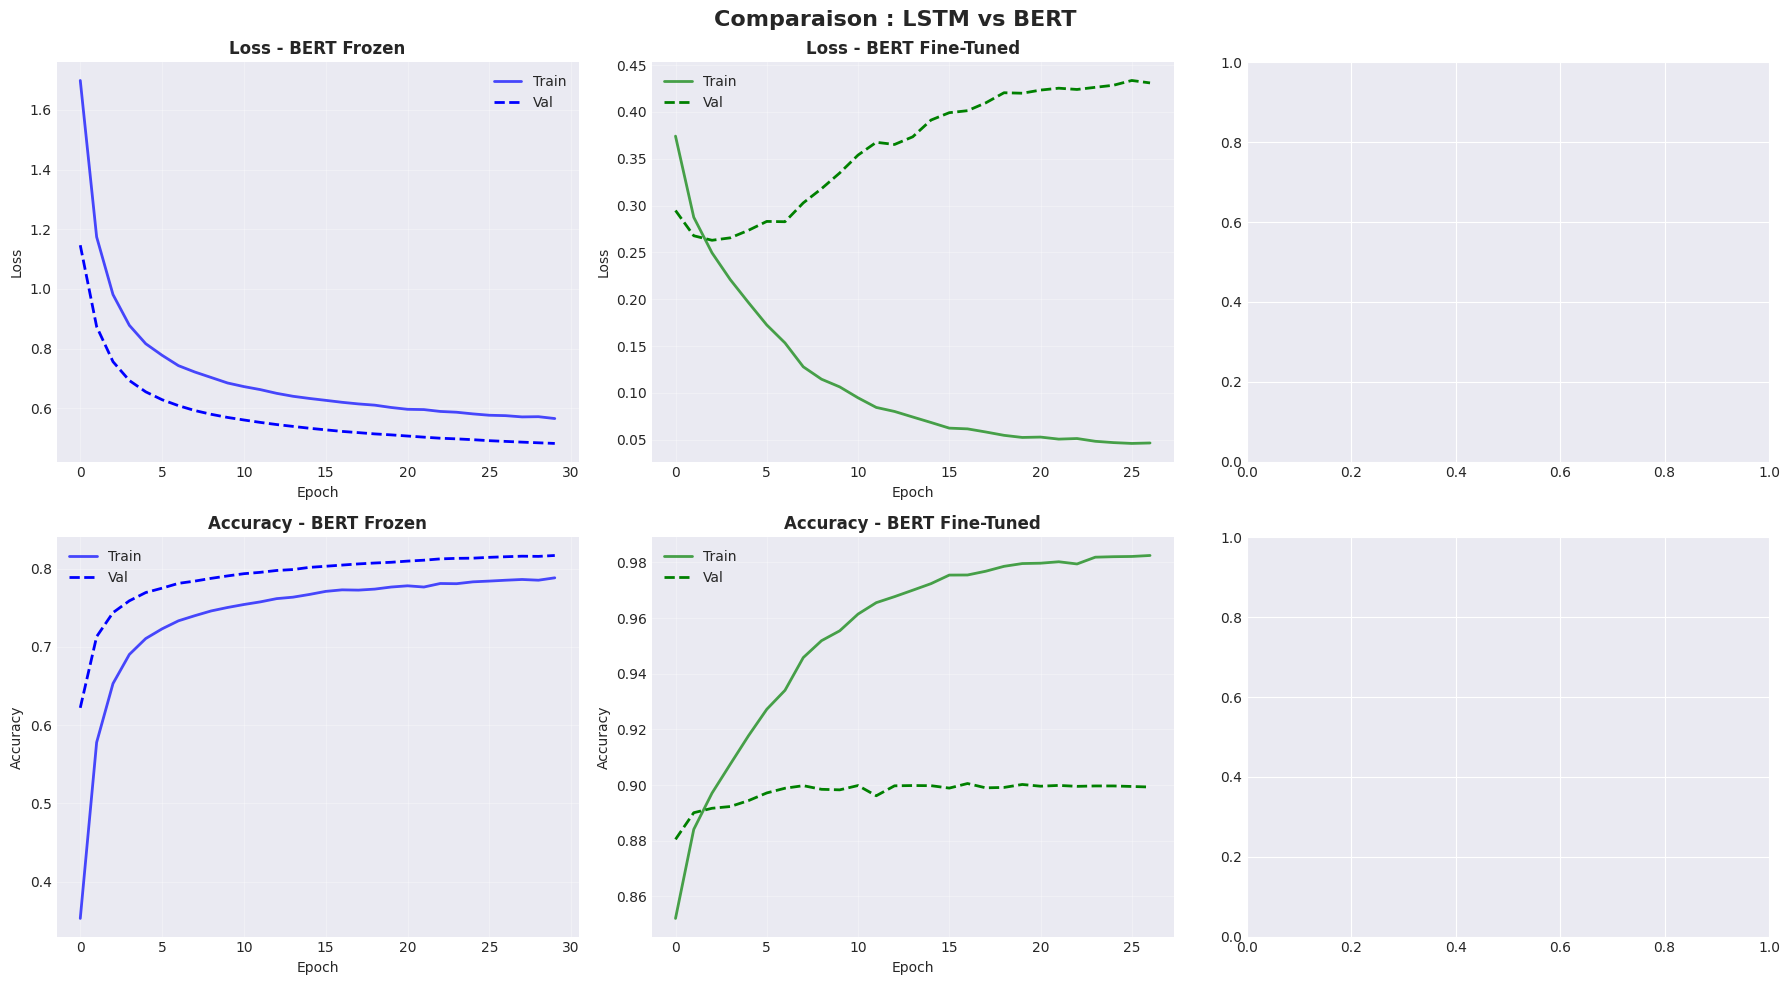

In [21]:
# Visualisation comparative
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparaison : LSTM vs BERT', fontsize=16, fontweight='bold')

models_histories = [
    ('BERT Frozen', history_bert_frozen, 'blue'),
    ('BERT Fine-Tuned', history_bert_ft, 'green')
]

# Loss
for idx, (name, history, color) in enumerate(models_histories):
    ax = axes[0, idx]
    ax.plot(history.history['loss'], label='Train', linewidth=2, color=color, alpha=0.7)
    ax.plot(history.history['val_loss'], label='Val', linewidth=2, color=color, linestyle='--')
    ax.set_title(f'Loss - {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

# Accuracy
for idx, (name, history, color) in enumerate(models_histories):
    ax = axes[1, idx]
    ax.plot(history.history['accuracy'], label='Train', linewidth=2, color=color, alpha=0.7)
    ax.plot(history.history['val_accuracy'], label='Val', linewidth=2, color=color, linestyle='--')
    ax.set_title(f'Accuracy - {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
bert_ft_model.save("model_half_2.keras")